In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv(r"D:\Churn_Modelling_with_nulls.csv")

In [28]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602.0,Hargrave,619.0,France,Female,NaN,2.0,0.00,1.0,1.0,1.0,101348.88,1.0
1,2,15647311.0,Hill,608.0,Spain,Female,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0
2,3,15619304.0,Onio,502.0,France,Female,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0
3,4,15701354.0,Boni,699.0,France,Female,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0
4,5,15737888.0,Mitchell,850.0,Spain,Female,43.0,NaN,125510.82,1.0,1.0,1.0,79084.10,0.0


In [29]:
df.shape

(10000, 14)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       9505 non-null   float64
 2   Surname          9467 non-null   object 
 3   CreditScore      9484 non-null   float64
 4   Geography        9498 non-null   object 
 5   Gender           9519 non-null   object 
 6   Age              9481 non-null   float64
 7   Tenure           9486 non-null   float64
 8   Balance          9503 non-null   float64
 9   NumOfProducts    9514 non-null   float64
 10  HasCrCard        9503 non-null   float64
 11  IsActiveMember   9503 non-null   float64
 12  EstimatedSalary  9519 non-null   float64
 13  Exited           9522 non-null   float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.1+ MB


In [31]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,9.505000e+03,9484.000000,9481.000000,9486.000000,9503.000000,9514.000000,9503.000000,9503.000000,9519.000000,9522.000000
mean,5000.50000,1.569096e+07,650.677562,38.928910,5.010120,76339.509882,1.530902,0.704199,0.513206,100143.227946,0.202373
std,2886.89568,7.199815e+04,96.530690,10.487475,2.888164,62410.870288,0.581199,0.456426,0.499852,57593.023485,0.401790
min,1.00000,1.556571e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,2500.75000,1.562856e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50903.280000,0.000000
50%,5000.50000,1.569067e+07,652.000000,37.000000,5.000000,97042.600000,1.000000,1.000000,1.000000,100187.430000,0.000000
75%,7500.25000,1.575334e+07,718.000000,44.000000,7.000000,127714.790000,2.000000,1.000000,1.000000,149464.930000,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


# Data Cleaning

In [32]:
df.isnull().sum()

RowNumber            0
CustomerId         495
Surname            533
CreditScore        516
Geography          502
Gender             481
Age                519
Tenure             514
Balance            497
NumOfProducts      486
HasCrCard          497
IsActiveMember     497
EstimatedSalary    481
Exited             478
dtype: int64

In [33]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [34]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\ANSH\AppData\Local\Temp\ipykernel_3816\4074283006.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [35]:
cat_cols = df.select_dtypes(include='object').columns

In [36]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\ANSH\AppData\Local\Temp\ipykernel_3816\1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [37]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df.drop(["RowNumber","CustomerId","Surname"],axis=1,inplace=True)

# Encoding

In [40]:
df.select_dtypes(include='object').columns

Index(['Geography', 'Gender'], dtype='object')

In [41]:
from sklearn.preprocessing import LabelEncoder

In [42]:
le = LabelEncoder()

In [43]:
df["Gender"] = le.fit_transform(df["Gender"])

In [44]:
df = pd.get_dummies(df, columns=["Geography"], drop_first=True)

In [45]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

# Train Test Split

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
X_train.shape

(8000, 11)

In [49]:
X_test.shape

(2000, 11)

In [51]:
y_train.shape

(8000,)

In [52]:
y_test.shape

(2000,)

# Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()

In [56]:
X_train = scaler.fit_transform(X_train)

In [58]:
X_train

array([[ 0.36563263,  0.8734364 , -0.66368845, ...,  1.40152424,
        -0.55944804, -0.5600258 ],
       [-0.21021507,  0.8734364 ,  0.31277272, ...,  1.70231165,
         1.7874761 , -0.5600258 ],
       [-0.98867585,  0.8734364 , -1.44485738, ..., -0.2587105 ,
        -0.55944804,  1.78563201],
       ...,
       [ 0.8881611 , -1.14490305, -0.07781175, ..., -0.14596866,
        -0.55944804, -0.5600258 ],
       [ 0.16301955,  0.8734364 ,  0.41041883, ..., -0.05177362,
        -0.55944804, -0.5600258 ],
       [ 0.48293494,  0.8734364 ,  1.19158776, ..., -0.83425445,
         1.7874761 , -0.5600258 ]], shape=(8000, 11))

In [57]:
X_test = scaler.transform(X_test)

In [59]:
X_test

array([[-0.59411354,  0.8734364 , -0.17545787, ..., -1.044322  ,
         1.7874761 , -0.5600258 ],
       [-0.30618969,  0.8734364 ,  0.41041883, ...,  0.81878232,
        -0.55944804, -0.5600258 ],
       [ 0.00306186, -1.14490305,  0.50806495, ..., -0.74554144,
        -0.55944804,  1.78563201],
       ...,
       [ 0.00306186, -1.14490305,  0.8010033 , ..., -1.19422245,
        -0.55944804, -0.5600258 ],
       [ 0.42961571,  0.8734364 , -0.9566268 , ..., -0.42143506,
        -0.55944804, -0.5600258 ],
       [-0.25287045,  0.8734364 ,  0.01983437, ...,  0.1293205 ,
         1.7874761 , -0.5600258 ]], shape=(2000, 11))

# Deep Learning

In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [63]:
model = Sequential()

model.add(Dense(16, activation="relu", input_shape=(X_train.shape[1],)))

model.add(Dense(8, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

C:\Users\ANSH\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [65]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8028 - loss: 0.4942 - val_accuracy: 0.8081 - val_loss: 0.4404
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8045 - loss: 0.4392 - val_accuracy: 0.8112 - val_loss: 0.4247
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8169 - loss: 0.4231 - val_accuracy: 0.8300 - val_loss: 0.4115
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8309 - loss: 0.4090 - val_accuracy: 0.8406 - val_loss: 0.4007
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8392 - loss: 0.3961 - val_accuracy: 0.8444 - val_loss: 0.3906
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8436 - loss: 0.3827 - val_accuracy: 0.8469 - val_loss: 0.3797
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.3698 - val_accuracy: 0.8487 - val_loss: 0.3705
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8545 - loss: 0.3598 - val_accuracy: 0.

In [66]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8480 - loss: 0.3564
Accuracy: 0.8479999899864197


# Prediction

In [67]:
pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [68]:
pred = (pred > 0.5).astype(int)

In [69]:
pred

array([[0],
       [0],
       [0],
       ...,
       [1],
       [0],
       [0]], shape=(2000, 1))

# Matrix

In [70]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, pred))

print(classification_report(y_test, pred))

[[1539   96]
 [ 208  157]]
              precision    recall  f1-score   support

         0.0       0.88      0.94      0.91      1635
         1.0       0.62      0.43      0.51       365

    accuracy                           0.85      2000
   macro avg       0.75      0.69      0.71      2000
weighted avg       0.83      0.85      0.84      2000



# Accuracy

In [71]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred)

0.848

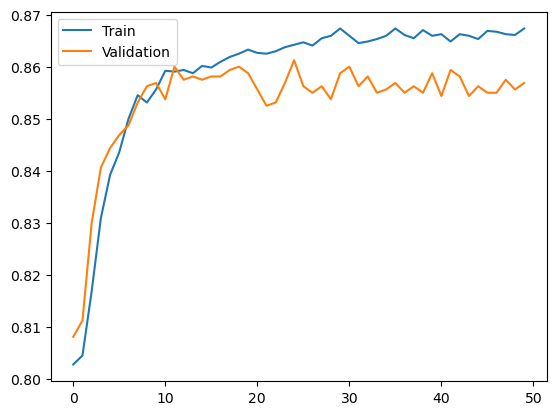

In [72]:
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.show()

# Loss Graph

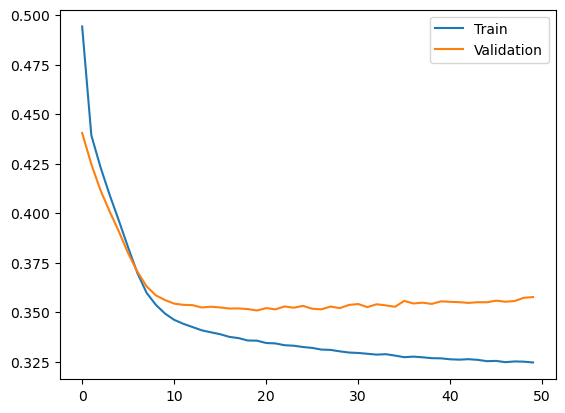

In [74]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()